In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from tqdm import tqdm 
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.lib import grdevices
from IPython.display import Image, display
import rpy2.robjects.packages as pkgs
from statsmodels.stats.multitest import multipletests
from itertools import product
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
import os
from rpy2.robjects.vectors import StrVector
utils = pkgs.importr('utils')
utils.chooseCRANmirror(ind=1)  # Select the first CRAN mirror
required_packages = StrVector(['lmerTest', 'performance'])#, 'dplyr', 'effectsize', 'emmeans', 'tidyr', 'ggplot2', 'performance', 'nlme', 'report', 'modelbased'])
utils.install_packages(required_packages)

def display_r_plot(plot):
    with grdevices.render_to_bytesio(grdevices.png, width=512, height=512, res=72) as img:
        ro.r.print(plot)
        
    img.seek(0)
    image = Image(data=img.read(), format='png')
    display(image)
    return image

pandas2ri.activate()
# pkgs.importr('dplyr')
# pkgs.importr('car')
# pkgs.importr('effectsize')
# pkgs.importr('emmeans')
# pkgs.importr('lmerTest')
# pkgs.importr('tidyr')
# pkgs.importr('ggplot2')
pkgs.importr('performance')
# pkgs.importr('nlme')
# pkgs.importr('report')
# pkgs.importr('modelbased')

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/lmerTest_3.1-3.tar.gz'

R[write to console]: Content type 'application/x-gzip'
R[write to console]:  length 195633 bytes (191 KB)

R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to con

Error in loadNamespace(j <- i[[1L]], c(lib.loc, .libPaths()), versionCheck = vI[[j]]) : 
  namespace ‘vctrs’ 0.4.2 is being loaded, but >= 0.5.0 is required
Calls: <Anonymous> ... namespaceImportFrom -> asNamespace -> loadNamespace
Execution halted


ERROR: lazy loading failed for package ‘lmerTest’
* removing ‘/Users/juliasantaniello/opt/anaconda3/envs/hitlbci/lib/R/library/lmerTest’
* restoring previous ‘/Users/juliasantaniello/opt/anaconda3/envs/hitlbci/lib/R/library/lmerTest’
* installing *source* package ‘performance’ ...
** package ‘performance’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (performance)
R[write to console]: 

R[write to console]: 
R[write to console]: The downloaded source packages are in
	‘/private/var/folders/bk/m5wzpcwd46xdzs4b0n4hp9ym0000gn/T/Rtmpl7NC7H/downloaded_packages’
R[write to console]: 
R[write to console]

rpy2.robjects.packages.Package as a <module 'performance'>

In [3]:
DATA_ROOT = 'Experiment/ParticipantData/fNIRS/FilteredData/'
files = [f for f in os.listdir(DATA_ROOT) if f.endswith('.csv') and '_b.csv' not in f]

dfs = []
for f in files:
    sub_df = pd.read_csv(os.path.join(DATA_ROOT, f))
    sub_df['condition'] = f.split('_')[1]
    dfs.append(sub_df)
df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=['Unnamed: 0', 'trial_id', 'MARKER'])
df = df[['pid', 'condition', 'time'] + [k for k in df.keys() if k not in ['pid', 'condition', 'time']]]

df = df.melt(id_vars=['pid', 'condition', 'time'], var_name='SIDE_WLEN_MEAS', value_name='value')

df[['SIDE', 'WLEN', 'MEAS']] = df['SIDE_WLEN_MEAS'].str.split('_', expand=True)
df = df.drop(columns=['SIDE_WLEN_MEAS'])

df.condition.unique()

df['DOMAIN'] = df['condition'].str[0]
df['INTER'] = df['condition'].str[1:]
df = df.drop(columns=['condition'])

df = df[(df.WLEN == 'O') & (df.MEAS == 'DSI')].drop(columns=['WLEN', 'MEAS'])

# df = df.groupby(['pid', 'SIDE', 'DOMAIN', 'INTER']).mean(numeric_only=True).reset_index()
df

,pid,time,value,SIDE,DOMAIN,INTER
0,22,2024-09-27 22:19:47.281618176,1.317972,L,F,W
1,22,2024-09-27 22:19:47.346659840,1.324740,L,F,W
2,22,2024-09-27 22:19:47.410644992,1.332869,L,F,W
3,22,2024-09-27 22:19:47.471101184,1.342102,L,F,W
4,22,2024-09-27 22:19:47.553235968,1.352246,L,F,W
...,...,...,...,...,...,...
450875,14,2024-09-20 21:30:42.653758976,0.574864,R,F,P
450876,14,2024-09-20 21:30:42.722071808,0.537369,R,F,P
450877,14,2024-09-20 21:30:42.789837824,0.500480,R,F,P
450878,14,2024-09-20 21:30:42.854604032,0.464219,R,F,P


In [4]:
from tqdm import tqdm
from mne.time_frequency import psd_array_multitaper,  tfr_array_morlet
from scipy.integrate import simpson

# VERY LOW FREQUENCY OSCILLATIONS
# HIGHER VLFO -> lower prefrontal activation

def freq_transform(fnirs_data, fs=5.2084):
    # VERY LOW FREQUENCY OSCILLATIONS
    # 0.02 - 50seconds
    # 0.07 - 14seconds
    psds, freqs = psd_array_multitaper(fnirs_data, 
                                        sfreq=fs, fmin=0.02, fmax=0.07,
                                        adaptive=True, low_bias=True, normalization='length',
                                        max_iter=2000, verbose="Warning")

    return simpson(psds, dx=freqs[1] - freqs[0])

df.head(10)

,pid,time,value,SIDE,DOMAIN,INTER
0,22,2024-09-27 22:19:47.281618176,1.317972,L,F,W
1,22,2024-09-27 22:19:47.346659840,1.324740,L,F,W
2,22,2024-09-27 22:19:47.410644992,1.332869,L,F,W
3,22,2024-09-27 22:19:47.471101184,1.342102,L,F,W
4,22,2024-09-27 22:19:47.553235968,1.352246,L,F,W
5,22,2024-09-27 22:19:48.469330176,1.363185,L,F,W
6,22,2024-09-27 22:19:48.532224768,1.374802,L,F,W
7,22,2024-09-27 22:19:48.609999104,1.386855,L,F,W
8,22,2024-09-27 22:19:48.671601152,1.398902,L,F,W
9,22,2024-09-27 22:19:48.734727936,1.410283,L,F,W


In [5]:
freq_df = df.groupby(['pid', 'SIDE', 'DOMAIN', 'INTER']).value.apply(freq_transform).rename('vlf').reset_index()
freq_df.vlf = np.log(freq_df.vlf)
freq_df = freq_df.groupby(['pid', 'SIDE', 'DOMAIN', 'INTER']).mean(numeric_only=True).reset_index()
freq_df.tail(1)

,pid,SIDE,DOMAIN,INTER,vlf
145,25,R,L,W,-0.791465


/var/folders/bk/m5wzpcwd46xdzs4b0n4hp9ym0000gn/T/ipykernel_92003/1122820885.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(kind='point', col="SIDE", data=freq_df, x='DOMAIN', y='vlf', hue='INTER', join=False, dodge=True)
/Users/juliasantaniello/opt/anaconda3/envs/hitlbci/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


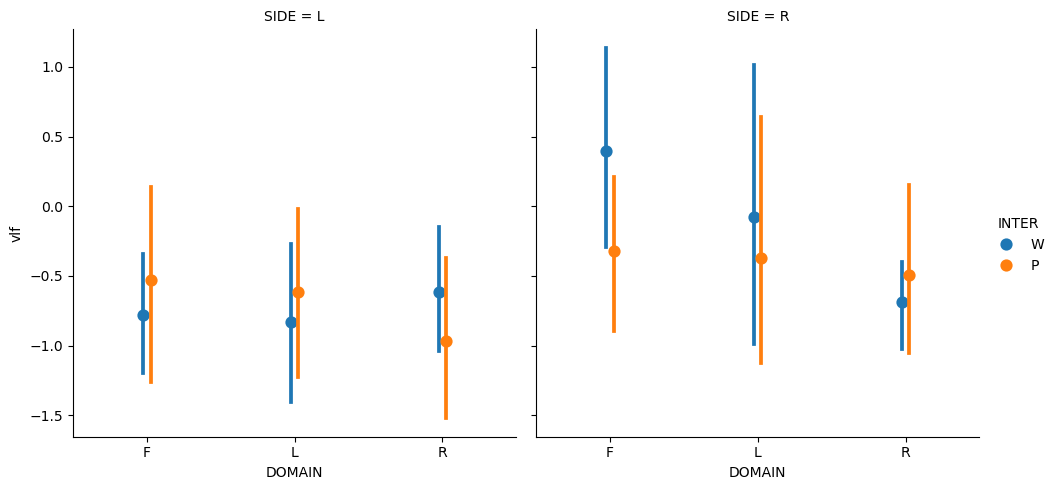

In [8]:
sns.catplot(kind='point', col="SIDE", data=freq_df, x='DOMAIN', y='vlf', hue='INTER', join=False, dodge=True)

<Axes: >

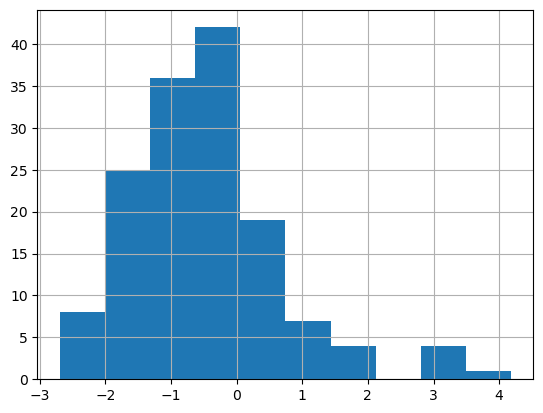

In [9]:
freq_df.vlf.hist()

In [ ]:
r_func = ro.r('''
    function(df) {
        df$pid <- as.factor(df$pid)
        df$DOMAIN <- as.factor(df$DOMAIN)
        df$INTER <- as.factor(df$INTER)

        # linear mixed model
        m <- lme4::lmer(vlf ~ DOMAIN * INTER + (1+DOMAIN|pid), data=df)
       
        # linear model
        # m <- lm(vlf ~ DOMAIN * INTER, data=df)
        print(summary(m))

        ava <- anova(m) 
        chk_plot <- check_model(m)

        return (list(ava, chk_plot))

    }
''')
for side, side_df in freq_df.groupby('SIDE'):
    if side == 'L': 
        continue
    ava, chk_plot = r_func(side_df)
    print("A")

    display_r_plot(chk_plot)
    
    ava = ro.conversion.rpy2py(ava)
    display(ava)

A
Linear mixed model fit by REML ['lmerMod']
Formula: vlf ~ DOMAIN * INTER + (1 + DOMAIN | pid)
   Data: df

REML criterion at convergence: 176.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.92486 -0.35972  0.03526  0.40595  1.92534 

Random effects:
 Groups   Name        Variance Std.Dev. Corr       
 pid      (Intercept) 1.6671   1.2912              
          DOMAINL     0.3426   0.5853    0.38      
          DOMAINR     0.2584   0.5083   -0.64 -0.07
 Residual             0.1500   0.3873              
Number of obs: 73, groups:  pid, 23

Fixed effects:
               Estimate Std. Error t value
(Intercept)    -0.04694    0.31971  -0.147
DOMAINL         0.08879    0.26650   0.333
DOMAINR        -0.37442    0.23748  -1.577
INTERW          0.10367    0.21284   0.487
DOMAINL:INTERW -0.02685    0.31300  -0.086
DOMAINR:INTERW  0.04155    0.27924   0.149

Correlation of Fixed Effects:
            (Intr) DOMAINL DOMAINR INTERW DOMAINL:
DOMAINL     -0.214            

In [ ]:
sns.catplot(kind='point', data=df, col='MEAS', row='SIDE', x='condition', hue='WLEN', y='value', join=False)